In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt  
import seaborn as sns
#dataset = fetch_california_housing()
#dataset = pd.read_csv(r'C:\Users\Gwanggu-ai-academy-park\boston.csv')

plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/My Drive/Colab Notebooks/boston/boston.csv')

#엑셀로 저장시험문제

df.to_excel("boston.xlsx")


# df.info()
# df.describe()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
# 컬럼명 한글 변환 딕셔너리
col_kr = {
    "CRIM": "범죄율",
    "ZN": "25,000평방피트 이상 주거지 비율",
    "INDUS": "비상업지역 비율",
    "CHAS": "찰스강 인접 여부",
    "NOX": "일산화질소 농도",
    "RM": "평균 방 개수",
    "AGE": "노후 건물 비율",
    "DIS": "고용센터까지 거리",
    "RAD": "고속도로 접근성",
    "TAX": "재산세율",
    "PTRATIO": "학생-교사 비율",
    "B": "흑인 비율 지수",
    "LSTAT": "하위 계층 비율",
    "MEDV": "주택 중간값(집값)"
}

# 컬럼명 변경
df = df.rename(columns=col_kr)

In [3]:
!apt-get update -qq
!apt-get install -y fonts-nanum
!rm -rf ~/.cache/matplotlib

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 60 not upgraded.


In [10]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

<!-- CRIM	범죄율
     ZN	대지 비율 (25,000 sq.ft 이상)
     INDUS	비상업 지역 비율
     CHAS	강 인접 여부 (1: 인접, 0: 아님)
     NOX	공기 오염도
     RM	평균 방 개수
     AGE	오래된 집 비율
     DIS	직장까지 거리
     RAD	고속도로 접근성
     TAX	재산세율
     PTRATIO	학생-교사 비율
     B	흑인 비율 지표
     LSTAT	저소득층 비율
     MEDV	집값 (타겟값) -->

최종 인사이트 = 주택가격에 영향을 미치는 요인을 분석하기

In [ ]:
# 데이터 전처리 및 구조확인
# print(df.columns)
# df.info()
# df.describe().T
# df.isnull().sum()
# df.shape
df = df.rename(columns={
    "CRIM": "범죄율",
    "ZN": "주거지비율(25,000평방피트 이상)",
    "INDUS": "비상업지역비율",
    "CHAS": "찰스강 인접 여부",
    "NOX": "질소산화물농도",
    "RM": "평균 방 개수",
    "AGE": "노후주택비율",
    "DIS": "직업센터거리",
    "RAD": "고속도로접근성",
    "TAX": "재산세율",
    "PTRATIO": "학생/교사비율",
    "B": "흑인거주지지수",
    "LSTAT": "하위계층비율",
    "MEDV": "주택가격(중앙값)"
})
# ===================인사이트===================
# 총 14 컬럼 에 506 행의 데이터가 있다
# 전부 숫자형 데이터이다
# 결측치가 없다
# 컬럼명을 한글로 분석완료 하였음





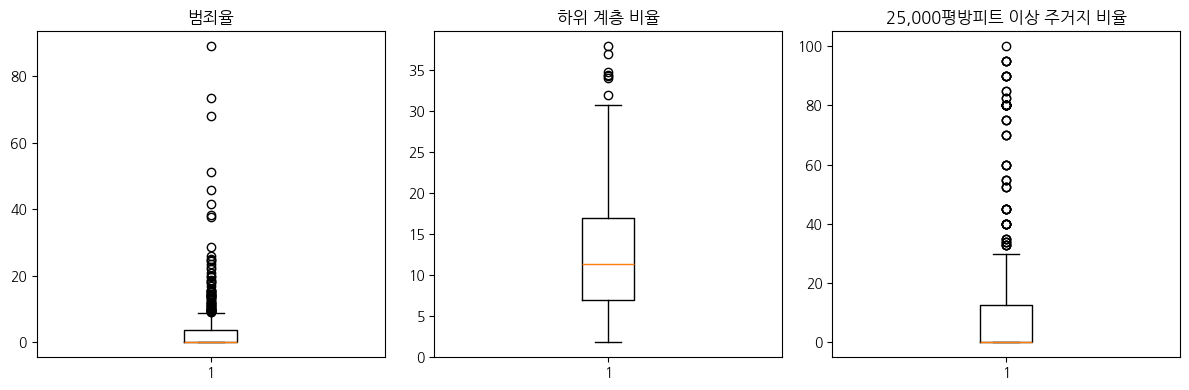

In [ ]:
#이상치확인

plt.figure(figsize=(12,4))

# 1번째 박스플롯
plt.subplot(1,3,1)
plt.boxplot(df["범죄율"])
plt.title("범죄율")

# 2번째 박스플롯
plt.subplot(1,3,2)
plt.boxplot(df["하위 계층 비율"])
plt.title("하위 계층 비율")

# 3번째 박스플롯
plt.subplot(1,3,3)
plt.boxplot(df["25,000평방피트 이상 주거지 비율"])
plt.title("25,000평방피트 이상 주거지 비율")

plt.tight_layout()
plt.show()

In [26]:
# 피처 엔지니어링
# 1.로그변환
df["범죄율"] = np.log1p(df["범죄율"])
df["하위 계층 비율"] = np.log1p(df["하위 계층 비율"])
df["25,000평방피트 이상 주거지 비율)"] = np.log1p(df["25,000평방피트 이상 주거지 비율"])


# 2. 평균 방 개수 구간화
df["방크기등급"] = pd.cut(
    df["평균 방 개수"],
    bins=[0,5,6.5,9],
    labels=["작음","보통","큼"]
)

# 3. 노후주택 여부
df["노후주택"] = (df["노후 건물 비율"] >= 80).astype(int)

# 4. 사회경제지수
# 범죄율 + 하위계층비율 합쳐서 의미있는 변수로 만듭니다.
df["사회경제지수"] = (
    df["범죄율"] *
    df["하위 계층 비율"]
)




array([[<Axes: title={'center': '범죄율'}>,
        <Axes: title={'center': '25,000평방피트 이상 주거지 비율'}>,
        <Axes: title={'center': '비상업지역 비율'}>,
        <Axes: title={'center': '찰스강 인접 여부'}>],
       [<Axes: title={'center': '일산화질소 농도'}>,
        <Axes: title={'center': '평균 방 개수'}>,
        <Axes: title={'center': '노후 건물 비율'}>,
        <Axes: title={'center': '고용센터까지 거리'}>],
       [<Axes: title={'center': '고속도로 접근성'}>,
        <Axes: title={'center': '재산세율'}>,
        <Axes: title={'center': '학생-교사 비율'}>,
        <Axes: title={'center': '흑인 비율 지수'}>],
       [<Axes: title={'center': '하위 계층 비율'}>,
        <Axes: title={'center': '주택 중간값(집값)'}>,
        <Axes: title={'center': '25,000평방피트 이상 주거지 비율)'}>,
        <Axes: title={'center': '노후주택'}>],
       [<Axes: title={'center': '사회경제지수'}>, <Axes: >, <Axes: >, <Axes: >]],
      dtype=object)

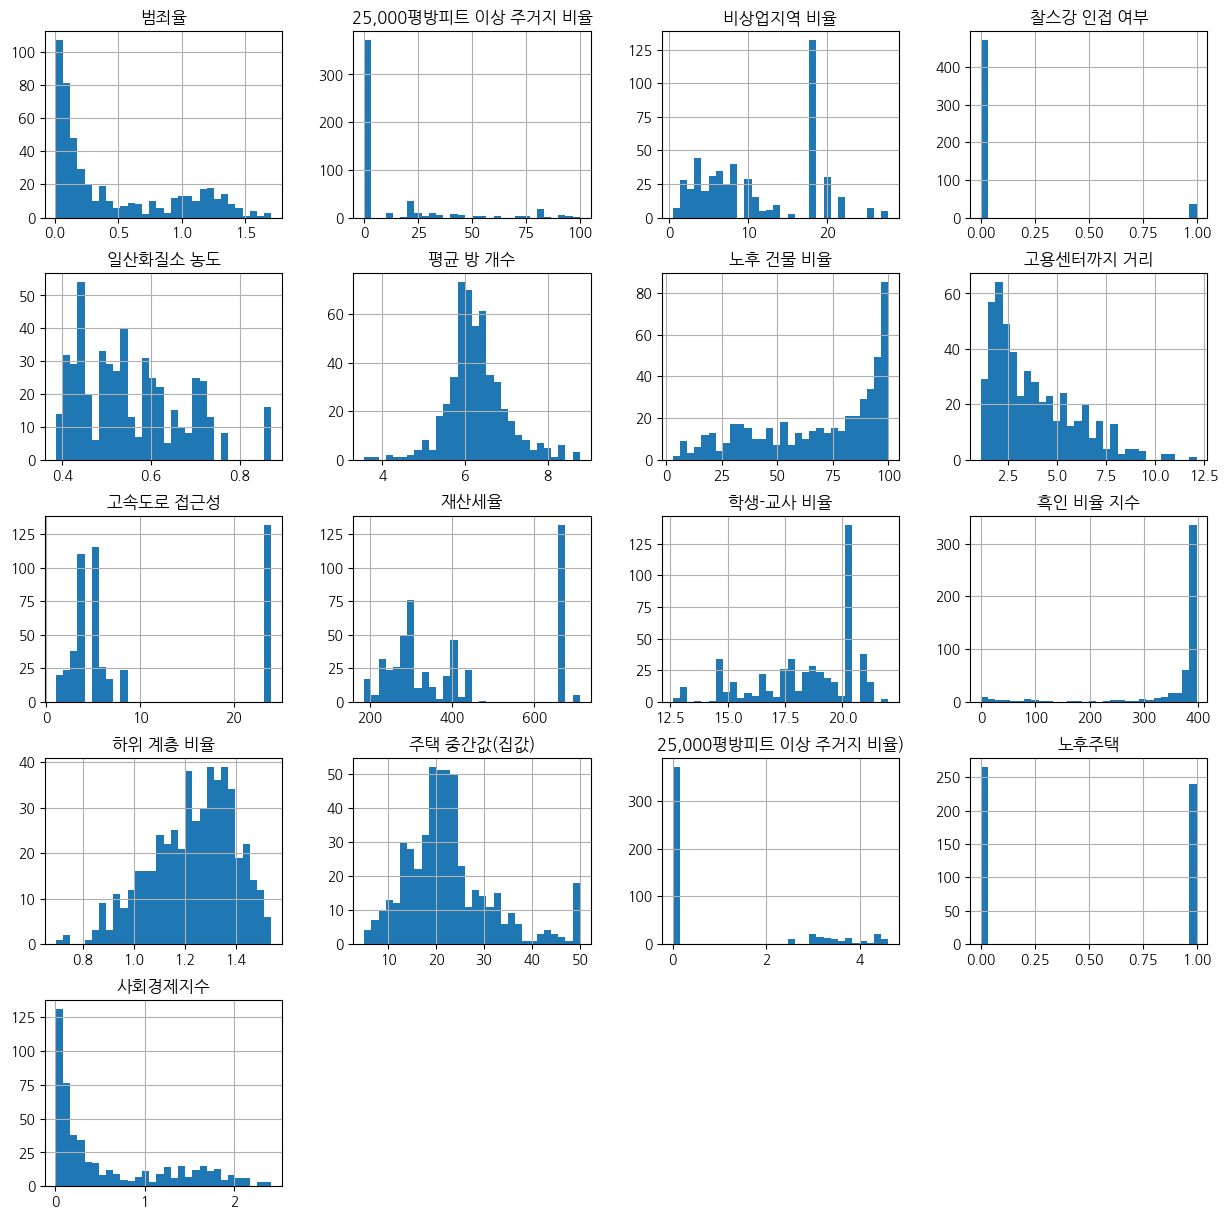

In [ ]:
## 1) 단변량 분석 및 기초통계량 확인

# 분석
# 1. 범죄율
# 평균적으로 대부분 지역은 범죄율이 없거나 낮다
# 일부지역에 범죄율이 많은곳이 있다
# 평균 과 중앙값의 차이가 많이난다 매우큰 이상치값이 있다고 해석할수있다

# 2. 25,000평방피트 이상 주거지 비율주거지비율
# df["25,000평방피트 이상 주거지 비율"].describe()
# 중앙값이 0이므로 절반의 지역이 0이다
# 평균과 중앙값 차이가 크다 오른쪽으로 치우친 분포(양의 왜도)
# 일부지역은 주거지비율이 매우 높다

# 3. 비상업지역 비율
# 비교적 최대 최소값이 극단적으로 차이가있지않다

# 4. 찰스강 인접 여부
# df["찰스강 인접 여부"].describe()*100
# 약 7프로 정도만 찰스강과 인접한 지역이다.
# 0과 1만 존재하는 이진형 변수이다.

# 5. 일산화질소 농도
# 비교적 균형적인 분포를 가진다

# 6. 평균 방 개수
# df["평균 방 개수"].describe()
# 가장 정규분포에 가까운 데이터를 가진다
# 지역별 평균 방 개수는 6개이다

# 7. 노후 건물 비율
# df["노후 건물 비율"].describe()
# 평균과 표준편차에 차이가 크다
# 지역별 노후주택비율의 차이가 존재한다

# 8.재산세율
# df["재산세율"].describe()
# 지역별 재산세율 차이가 크다
# 일부 높은 재산율이 평균을 증가시켰다

# 9."주택 중간값(집값)"
# df["주택 중간값(집값)"].describe()
# 평균과 중앙값의 차이가 비슷하다 주택가격은 비교적 균형적인 분포를 보인다
# 일부 고가의 주택이 존재하지만 대부분 25이하에 분포되어있다.

# 10. 하위 계층 비율
# df["하위 계층 비율"].describe()
# 비교적 평균과 중앙값이 큰차이가 없어 균형적인 분포를보인다
# 표준편차 와 평균 차이를 확인해보니 지역별 하위계층비율의 차이가 존재한다
# 최소 최대값 차이를 확인해보니 일부지역에는 하위계층비율이 매우 높으며 이상치가 존재할 가능성이있다

# 11.노후주택
# 노후주택 인 집과 아닌집이 반반섞여있다
# 이진변수이다 0아니면 1

# 12. 사회경제지수 (범죄율 + 하위계층비율)
# 지역별 격차가 존재 (균등하지 않음)
# 대부분 지역은 낮은 사회경제 수준
# 일부 부유 지역이 분포를 끌어올림
#

df.hist(figsize=(15, 15), bins=30)


In [39]:
df["사회경제지수"].describe()


,사회경제지수
count,506.000000
mean,0.616847
std,0.675161
min,0.006440
25%,0.083676
50%,0.257930
75%,1.179177
max,2.420613
